In [2]:
import numpy as np
import pandas as pd
import seaborn as sns                      # 통계 전용 시각화 - matplotlib 같이 사용 가능 

import matplotlib.pyplot as plt            # 그래프 출력 옵션 (Detail)
import matplotlib as mpl                   # 외적인(큰틀) 옵션 - 한글, 사이즈 등  

mpl.rc('font', family='Malgun Gothic')     # 폰트 경로 - C:\Windows\Fonts\Malgun Gothic
plt.rcParams['axes.unicode_minus']=False   # 마이너스 설정 

# 실습 문제
## 데이터 가져오기 

In [5]:
dye=pd.read_csv('./염색공정전체데이터.csv', encoding='cp949')

In [6]:
dye.shape

(32608, 18)

In [7]:
dye.head()

,LOT번호,검사차수,작업명,공정코드,설비번호,단위중량(kg),투입중량(kg),염색길이(m),투입중량/길이,투입중량/액량,공정진행시간(%),지시온도,진행온도,포속1,포속2,포속3,포속4,염색색차 DE
0,F2201280039,0,원단검사,F12-1203,FCM08,324.0,44.6,41.0,1.087805,0.0446,0.19,30.0,10.9,0,0,0,0,0.753096
1,F2201280039,0,원단검사,F12-1203,FCM08,324.0,44.6,41.0,1.087805,0.0446,0.39,30.0,10.3,16,1,16,1,0.753096
2,F2201280039,0,원단검사,F12-1203,FCM08,324.0,44.6,41.0,1.087805,0.0446,0.58,30.0,10.3,68,2,16,1,0.753096
3,F2201280039,0,원단검사,F12-1203,FCM08,324.0,44.6,41.0,1.087805,0.0446,0.77,30.0,10.2,69,3,138,2,0.753096
4,F2201280039,0,원단검사,F12-1203,FCM08,324.0,44.6,41.0,1.087805,0.0446,0.97,30.0,10.8,69,3,138,2,0.753096


In [8]:
dye.info()          # 자료형 Type, 결측치 

<class 'pandas.DataFrame'>
RangeIndex: 32608 entries, 0 to 32607
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LOT번호      32608 non-null  str    
 1   검사차수       32608 non-null  str    
 2   작업명        32608 non-null  str    
 3   공정코드       32608 non-null  str    
 4   설비번호       32608 non-null  str    
 5   단위중량(kg)   32608 non-null  float64
 6   투입중량(kg)   32608 non-null  float64
 7   염색길이(m)    32608 non-null  float64
 8   투입중량/길이    32608 non-null  float64
 9   투입중량/액량    32608 non-null  float64
 10  공정진행시간(%)  32608 non-null  float64
 11  지시온도       32608 non-null  float64
 12  진행온도       32608 non-null  float64
 13  포속1        32608 non-null  int64  
 14  포속2        32608 non-null  int64  
 15  포속3        32608 non-null  int64  
 16  포속4        32608 non-null  int64  
 17  염색색차 DE    32608 non-null  float64
dtypes: float64(9), int64(4), str(5)
memory usage: 4.5 MB


## 범주형 자료형

In [9]:
dye.describe(include='str')

,LOT번호,검사차수,작업명,공정코드,설비번호
count,32608,32608,32608,32608,32608
unique,120,3,2,1,7
top,F2208120070,0,원단검사,F12-1203,FCM08
freq,603,27944,27922,32608,8952


In [10]:
dye['LOT번호'].nunique()       # LOT 번호 : 생산 단위 식별화는 고유번호 (Batch)

120

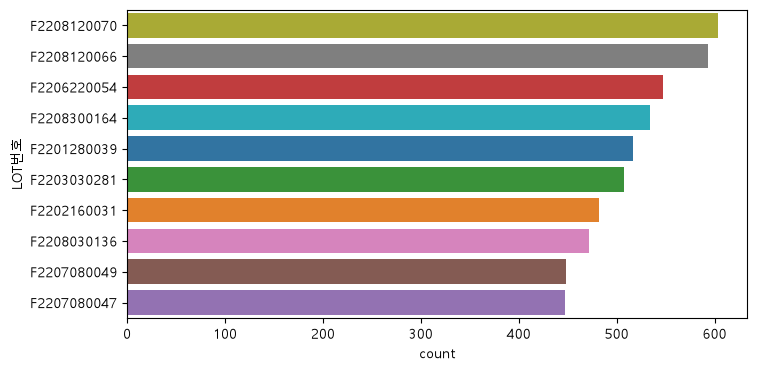

In [11]:
top10=dye['LOT번호'].value_counts().head(10).index     # top10.index[20:41]
df_top10=dye[dye['LOT번호'].isin(top10)]               # 상위 10개에 해당하는 데이터만 필터링

plt.figure(figsize=(8, 4))
sns.countplot(data=df_top10, y='LOT번호', order=top10, hue='LOT번호')
plt.show()

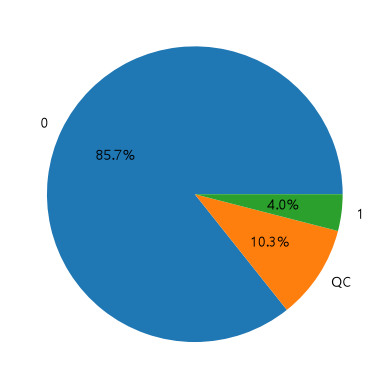

In [12]:
num=dye['검사차수'].value_counts()

plt.pie(x=num.values,
        labels=num.index, 
        autopct='%.1f%%')        # explode=[0, 0, 0]

plt.show()

In [13]:
dye['작업명'].value_counts()         # 작업명 : 염색(생산 고정), 원단검사(검사공정)

작업명
원단검사    27922
염색       4686
Name: count, dtype: int64

In [14]:
dye['공정코드'].value_counts()       # 공정코드 : 작업공정 라인

공정코드
F12-1203    32608
Name: count, dtype: int64

In [15]:
dye['설비번호'].value_counts()       # 설비번호 : 공정이 진행된 염색기 번호 

설비번호
FCM08    8952
FCM05    6171
FCM06    5774
FCM11    4442
FCM12    3699
FCM15    1903
FCM07    1667
Name: count, dtype: int64

## 연속형 자료형
- 이상치
- 포속1 ~ 포속4 : 롤러를 타고 이동하는 속도를 구간별 또는 실시간으로 측정값 
    - 포속1 (투입 및 준비 단계)
        - 원단을 염색기에 처음 공급하거나, 염색 전 온도를 올리며 정련(세척)할 때의 속도
    - 포속2 (본 염색 단계)
        - 염료를 투입하고 본격적으로 원단에 색을 입히는 단계
        - 염료가 원단 전체에 얼룩 없이 고르게 스며들도록 일정하고 안정적인 속도(등포속) 유지가 핵심
    - 포속3 (고정 및 고온 단계)
        - 염료가 섬유에 완전히 결합하도록 온도를 높여 고정(Fixation)하는 단계의 속도
    - 포속4 (수세 및 배출 단계)
        - 염색이 끝난 후 남은 염료를 씻어내고(수세), 원단을 밖으로 빼낼 때의 속도
- 투입중량/길이
- 투입중량/액량

In [16]:
dye.columns

Index(['LOT번호', '검사차수', '작업명', '공정코드', '설비번호', '단위중량(kg)', '투입중량(kg)',
       '염색길이(m)', '투입중량/길이', '투입중량/액량', '공정진행시간(%)', '지시온도', '진행온도', '포속1',
       '포속2', '포속3', '포속4', '염색색차 DE'],
      dtype='str')

In [17]:
num=dye[['투입중량/액량', '포속1', '포속2', '포속3', '포속4']]
num.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
투입중량/액량,32608.0,0.07,0.02,0.02,0.05,0.07,0.08,0.11
포속1,32608.0,68.33,65.45,0.00,39.00,65.00,87.00,2179.00
포속2,32608.0,153.31,155.75,0.00,49.00,108.00,210.00,1311.00
포속3,32608.0,118.58,286.77,0.00,47.00,81.00,108.00,6415.00
포속4,32608.0,99.15,123.12,0.00,20.00,67.00,129.00,1057.00


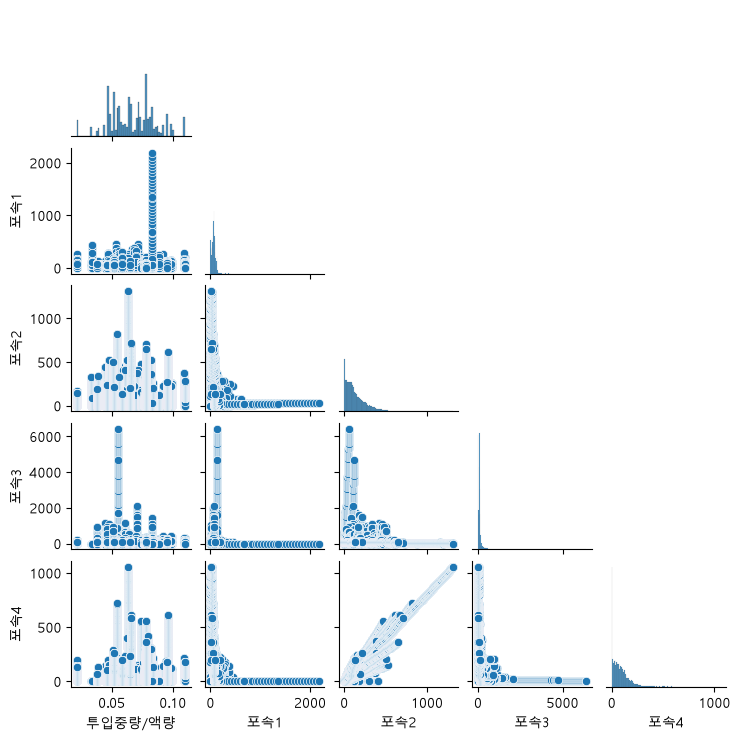

In [21]:
sns.pairplot(data=num, corner=True, height=1.5, aspect=1)
plt.show()

- 포속1의 평균이 68.33이라는 것은 원단이 1분에 약 68m의 속도 / 포속2는 약 153m/min / 포속3은 약 118m/min 정도

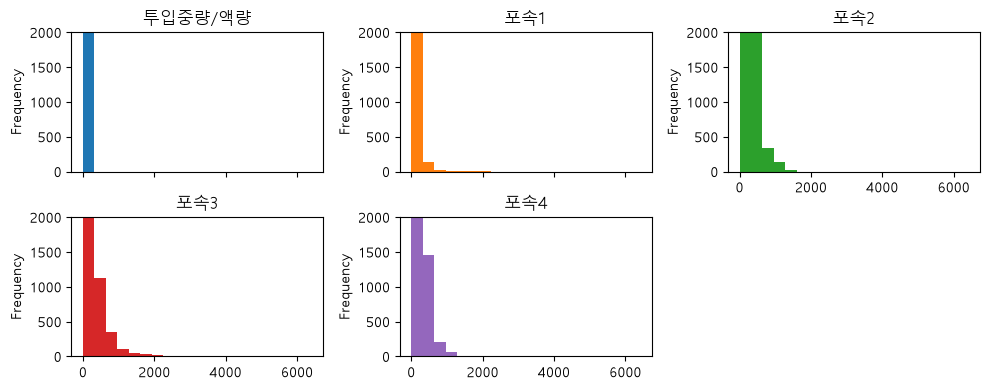

In [19]:
num.plot(kind='hist',       # 히스토그램(histogram) 생성
         bins=20,           # 구간(bin)을 20개로 나누기
         ylim=(0, 2000),    # y축 범위를 0~2000으로 고정
         figsize=(10, 4),   # 전체 그림 크기 (가로 10, 세로 4)
         subplots=True,     # 각 컬럼을 개별 subplot으로 출력
         layout=(2, 3),     # subplot 배치 (2행 × 3열)
         legend=False,      # 범례 표시 안 함
         title=list(num.columns))  # 각 subplot 제목을 컬럼명으로 설정
plt.tight_layout()
plt.show()

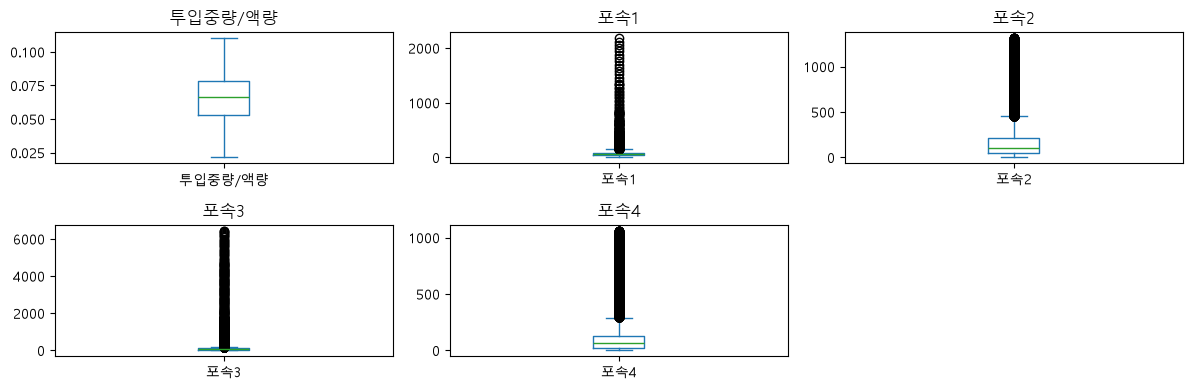

In [20]:
num.plot(kind='box', 
         figsize=(12, 4),
         subplots=True, 
         layout=(2, 3),
         title=list(num.columns))
plt.tight_layout()
plt.show()

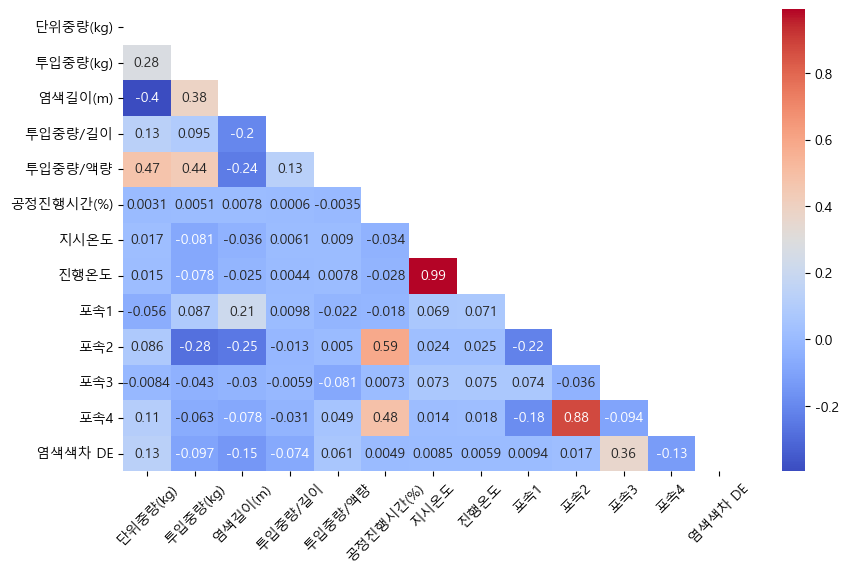

In [56]:
num_corr=dye.corr(numeric_only=True)

# plt.figure(figsize=(10, 6))
# sns.heatmap(num_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
# plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(num_corr,
            annot=True, 
            cmap='coolwarm', 
            mask=np.triu(np.ones_like(num_corr, dtype=bool)))

plt.xticks(rotation=45)    # 만약 글씨가 길다면 45도 기울여서 겹침 방지
plt.show()

## 불량률 원인분석

In [72]:
dye['불량여부']=(dye['염색색차 DE'] > 3).astype(int)      

In [74]:
bad=dye[dye['불량여부'] == 1]

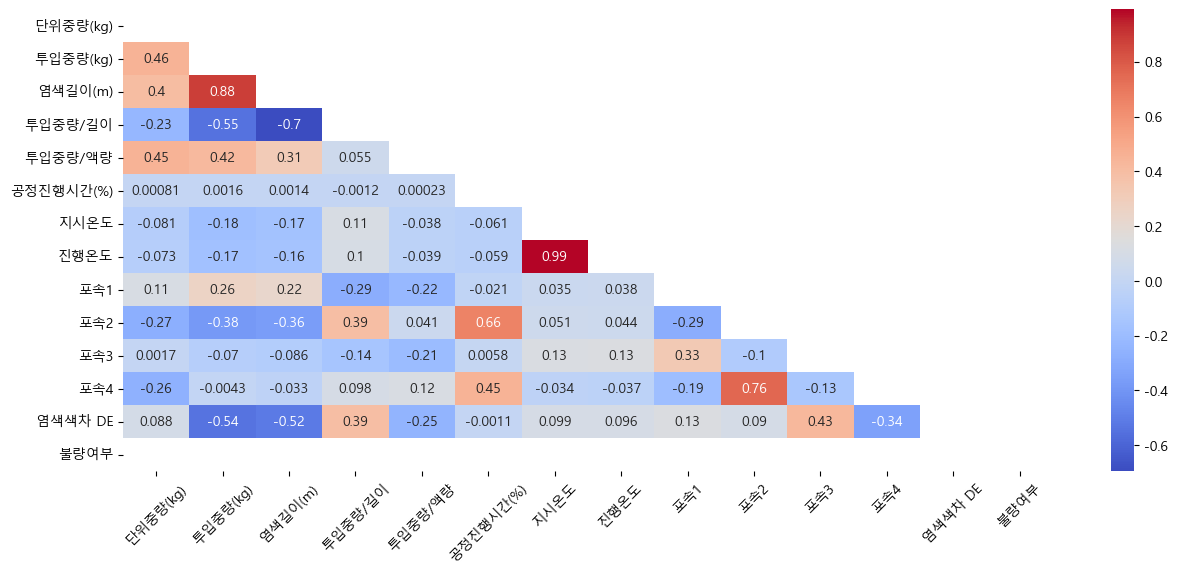

In [76]:
num_corr=bad.corr(numeric_only=True)

plt.figure(figsize=(15, 6))
sns.heatmap(num_corr,
            annot=True, 
            cmap='coolwarm', 
            mask=np.triu(np.ones_like(num_corr, dtype=bool)))

plt.xticks(rotation=45)    
plt.show()

In [196]:
defact=dye.groupby('불량여부')[['투입중량/길이', '투입중량/액량', '포속1', '포속2', '포속3', '포속4', '공정진행시간(%)']].mean()
defact

# 포속 3 튄다. 포속 힘을 못 받는다. 

,투입중량/길이,투입중량/액량,포속1,포속2,포속3,포속4,공정진행시간(%)
불량여부,,,,,,,
0,5.507463,0.066362,68.363732,154.572338,99.091991,103.404411,49.720863
1,1.496681,0.071348,68.167575,146.265294,227.358167,75.400162,50.181708


In [204]:
defact=dye.groupby(['설비번호', '불량여부'])[['투입중량/길이','투입중량/액량', '포속1', '포속2', '포속3', '포속4', '공정진행시간(%)']].mean()
defact.round(2)   

투입중량/길이  투입중량/액량     포속1     포속2     포속3     포속4  공정진행시간(%)
설비번호  불량여부                                                             
FCM05 0        7.22     0.08   72.12  119.36  103.12   85.78      49.53
      1        1.04     0.07   70.25  125.26  425.79   78.26      50.18
FCM06 0        6.22     0.07   47.08  177.86   94.06  105.48      49.39
FCM07 0        0.65     0.07   91.88   58.80   80.69   68.39      50.24
      1        0.64     0.07   93.77   60.47   87.30   66.60      50.24
FCM08 0        4.19     0.06   51.26  243.30  145.95  163.74      49.65
      1        2.18     0.08   49.67  270.33  236.97  164.41      50.11
FCM11 0        9.40     0.06   72.12   83.42   74.63   90.91      50.22
      1        0.69     0.08   74.93   54.09   76.26   57.05      50.31
FCM12 0        4.59     0.07  105.23  103.90    0.00    0.00      49.68
      1        2.72     0.06   57.92  172.65    0.00    0.00      50.15
FCM15 0        0.12     0.05  125.50   57.34  110.09   72.13      50.18

In [210]:
dye['LOT번호'].nunique()

120

In [212]:
bad=dye[dye['불량여부'] == 1]
bad.groupby(['LOT번호', '설비번호']).size().unstack(fill_value=0)   # MultiIndex의 한 레벨을 열(Column)로 변환하는 함수

설비번호,FCM05,FCM07,FCM08,FCM11,FCM12
LOT번호,,,,,
F2202210104,0,224,0,0,0
F2202210107,268,0,0,0,0
F2202210108,259,0,0,0,0
F2203030281,0,0,507,0,0
F2203080139,0,208,0,0,0
F2203080141,0,129,0,0,0
F2203080148,0,256,0,0,0
F2204290025,0,0,0,0,420
F2206090076,223,0,0,0,0


In [ ]:
# End Of ---------------------------------------------------